## 1. Introduction: 
 I trained four models – two custom CNN architectures built from scratch, and two transfer-learning models (VGG16 and MobileNetV2, with ImageNet weights). Each model is evaluated under various hyperparameters (learning rates, activation functions, epochs), and the best configuration for each is selected based on validation performance. Results (accuracy, loss metrics, and training plots) are saved in the results/ folder for clarity and reuse.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras import layers, models, optimizers, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import roc_auc_score, roc_curve, auc

## 2. Dataset Overview and Preprocessing

Loading data and preparing it for modeling. The Intel Image Classification dataset consists of ~25,000 images (150x150 resolution) of natural scenes in 6 categories: buildings, forest, glacier, mountain, sea, and street​. The task is to classify each image into the correct scene category. 

This project explores both custom Convolutional Neural Networks (CNNs) and pre-trained CNN models (VGG16 and MobileNetV2) to compare their performance on this multi-class classification task. Note: The dataset is not included in this repo; it can be downloaded from Kaggle (see link below).

In [2]:
base_dataset_path = "C:/Users/sidha/Desktop/2024/Deeplearning/IntelDataset"
train_path = os.path.join(base_dataset_path, "seg_train/seg_train")
test_path = os.path.join(base_dataset_path, "seg_test/seg_test")
pred_path = os.path.join(base_dataset_path, "seg_pred/seg_pred")

## 3. Model Architectures

In [3]:
# Augmentation ONLY for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # Split training data into train/val
)

# Only rescale for validation data
valid_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Only rescale for test data
test_datagen = ImageDataGenerator(rescale=1./255)

# Train generator with augmentation
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = valid_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


## 4. Compilation and Hyperparameter Settings

In [5]:
# Model builders
def build_model_mobilenet_v2():
    """
    Builds a model based on a pre-trained MobileNetV2 backbone.
    """
    base_model = MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
    base_model.trainable = True  # Set to True if you want to fine-tune layers from MobileNetV2

    # Add custom layers on top of the base model
    x = base_model.output
    x = GlobalAveragePooling2D()(x)  # Use GlobalAveragePooling2D to reduce the number of parameters
    x = Flatten()(x)
    x = Dense(128, kernel_initializer='he_uniform')(x)  # Add a Dense layer with 128 units
    x = Dropout(0.5)(x)  # Dropout for regularization
    x = BatchNormalization()(x)  # Batch normalization
    x = Activation('relu')(x)
    predictions = Dense(6, activation='softmax')(x)  # Output layer for 6 classes

    # Configure the model
    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer=Adam(lr=0.0001),  # Using a smaller learning rate
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [6]:
def build_model_vgg16():
    """
    Builds a model based on a pre-trained VGG16 backbone.
    """
    base_model = VGG16(input_shape=(150, 150, 3), include_top=False, weights='imagenet')
    base_model.trainable = False  # Freeze base model layers
    
    model = models.Sequential([
        base_model,
        layers.Flatten(),
        layers.Dense(128, activation='relu'),  # Reduced from 256 to 128
        layers.Dropout(0.5),
        layers.Dense(6, activation='softmax')  # For 6 classes
    ])
    
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model

In [7]:
def build_model_custom_1():
    """
    Builds the first custom model with a simple architecture.
    """
    model = models.Sequential([
        Input(shape=(150, 150, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),  # Removed one Conv2D layer
        layers.Dense(256, activation='relu'),  # Reduced from 512 to 256
        layers.Dense(6, activation='softmax')  # For 6 classes
    ])
    
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

 ## 5. Model Training and Evaluation

In [8]:
def build_model_custom_2():
    """
    Builds a second custom model with a different architecture for experimentation.
    """
    model = models.Sequential([
        Input(shape=(150, 150, 3)),
        layers.Conv2D(32, (2, 2), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (2, 2), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (2, 2), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(512, activation='relu'), 
        layers.Dropout(0.5),
        layers.Dense(6, activation='softmax') 
    ])
    
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

### 5.1 Training Function

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

def train_model(model, train_gen, val_gen, epochs=25, name="model"):
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
    checkpoint = ModelCheckpoint(
        filepath=f'models/{name}_best.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    history = model.fit(train_gen, validation_data=val_gen, epochs=epochs,
                        callbacks=[early_stop, reduce_lr, checkpoint])
    return history

### 5.2 Model Dictionary and Training Loop

In [15]:
import os
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

model_histories = {}

models_info = {
    'VGG16': build_model_vgg16,
    'MobileNetV2': build_model_mobilenet_v2,
    'CustomModel1': build_model_custom_1,
    'CustomModel2': build_model_custom_2
}

### 5.3 Train Models and Save Plots


🔧 Training VGG16...

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 4, 4, 512)         14714688  
_________________________________________________________________
flatten_2 (Flatten)          (None, 8192)              0         
_________________________________________________________________
dense_4 (Dense)              (None, 128)               1048704   
_________________________________________________________________
dropout_2 (Dropout)          (None, 128)               0         
_________________________________________________________________
dense_5 (Dense)              (None, 6)                 774       
Total params: 15,764,166
Trainable params: 1,049,478
Non-trainable params: 14,714,688
_________________________________________________________________
Epoch 1/25
351/351 [==============================] - 500s 1s/step - loss: 0.8

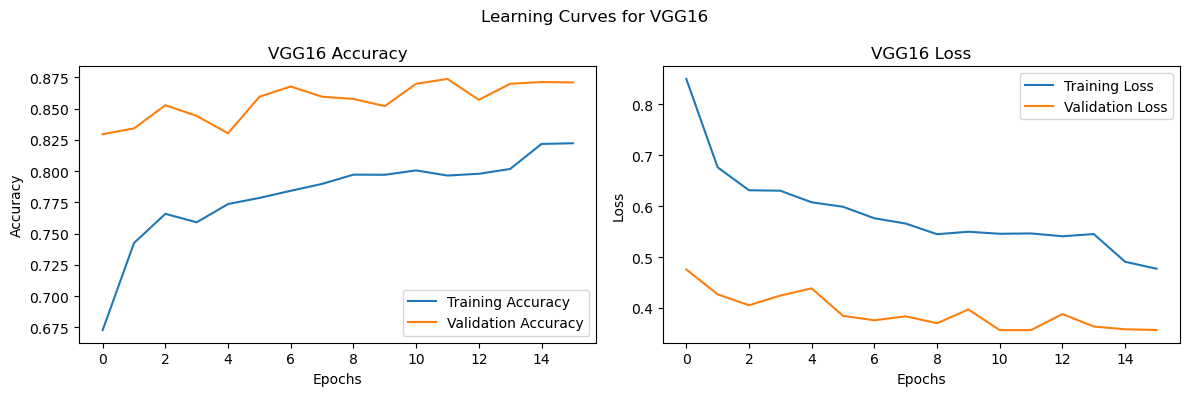


🔧 Training MobileNetV2...



c:\ProgramData\anaconda3\envs\new_env\lib\site-packages\tensorflow\python\keras\optimizer_v2\optimizer_v2.py:374: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  warnings.warn(


Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_4 (InputLayer)            [(None, 150, 150, 3) 0                                            
__________________________________________________________________________________________________
Conv1 (Conv2D)                  (None, 75, 75, 32)   864         input_4[0][0]                    
__________________________________________________________________________________________________
bn_Conv1 (BatchNormalization)   (None, 75, 75, 32)   128         Conv1[0][0]                      
__________________________________________________________________________________________________
Conv1_relu (ReLU)               (None, 75, 75, 32)   0           bn_Conv1[0][0]                   
______________________________________________________________________________________________

c:\ProgramData\anaconda3\envs\new_env\lib\site-packages\tensorflow\python\keras\utils\generic_utils.py:494: CustomMaskWarning: Custom mask layers require a config and must override get_config. When loading, the custom mask layer must be passed to the custom_objects argument.
  warnings.warn('Custom mask layers require a config and must override '


Epoch 2/25
351/351 [==============================] - 156s 443ms/step - loss: 0.3970 - accuracy: 0.8695 - val_loss: 0.4529 - val_accuracy: 0.8520

Epoch 00002: val_accuracy improved from 0.68545 to 0.85200, saving model to models\MobileNetV2_best.h5
Epoch 3/25
351/351 [==============================] - 154s 437ms/step - loss: 0.3349 - accuracy: 0.8894 - val_loss: 0.3146 - val_accuracy: 0.8951

Epoch 00003: val_accuracy improved from 0.85200 to 0.89515, saving model to models\MobileNetV2_best.h5
Epoch 4/25
351/351 [==============================] - 154s 437ms/step - loss: 0.3105 - accuracy: 0.8966 - val_loss: 0.3844 - val_accuracy: 0.8695

Epoch 00004: val_accuracy did not improve from 0.89515
Epoch 5/25
351/351 [==============================] - 154s 438ms/step - loss: 0.2758 - accuracy: 0.9086 - val_loss: 0.3018 - val_accuracy: 0.9080

Epoch 00005: val_accuracy improved from 0.89515 to 0.90799, saving model to models\MobileNetV2_best.h5
Epoch 6/25
351/351 [============================

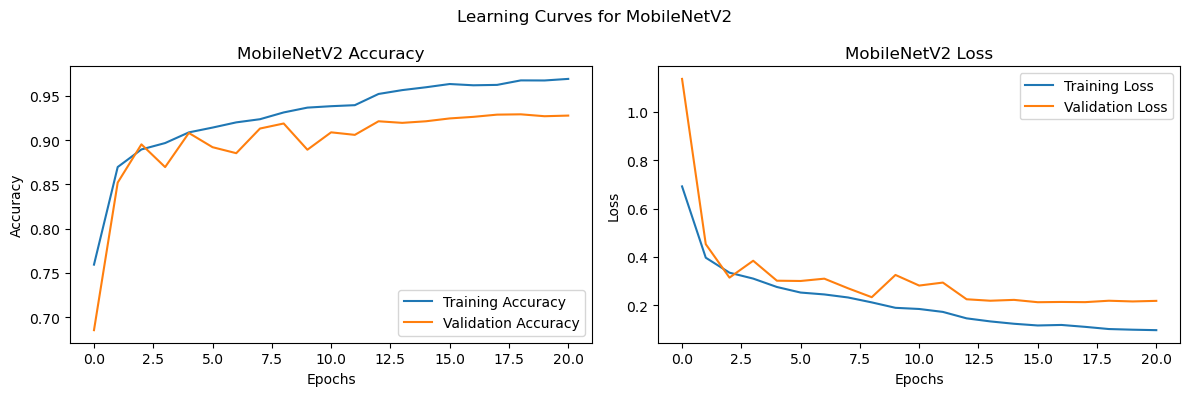


🔧 Training CustomModel1...

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 148, 148, 32)      896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 74, 74, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 72, 72, 64)        18496     
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 36, 36, 64)        0         
_________________________________________________________________
flatten_4 (Flatten)          (None, 82944)             0         
_________________________________________________________________
dense_8 (Dense)              (None, 256)               21233920  
_________________________________________________________________
dense_9 (Dense)          

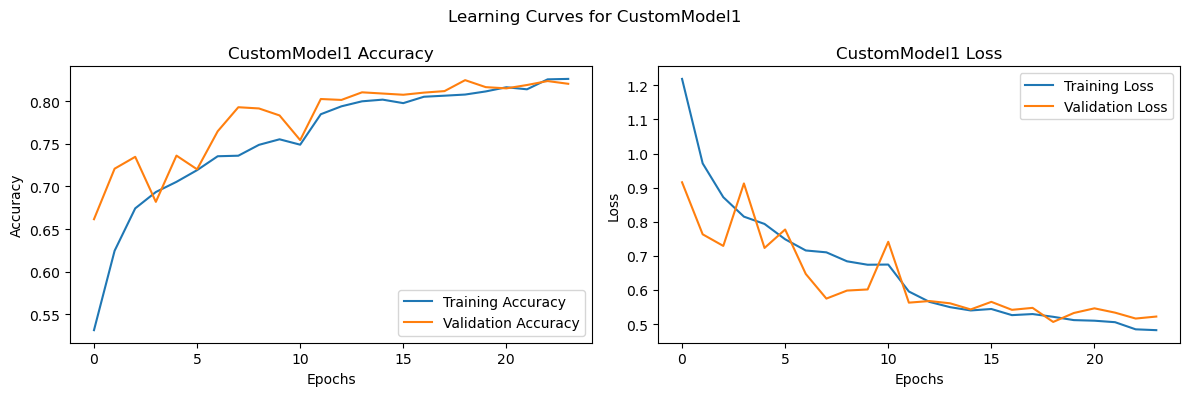


🔧 Training CustomModel2...

Model: "sequential_4"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_2 (Conv2D)            (None, 149, 149, 32)      416       
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 74, 74, 32)        0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 73, 73, 64)        8256      
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 36, 36, 64)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 35, 35, 128)       32896     
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 17, 17, 128)       0         
_________________________________________________________________
flatten_5 (Flatten)      

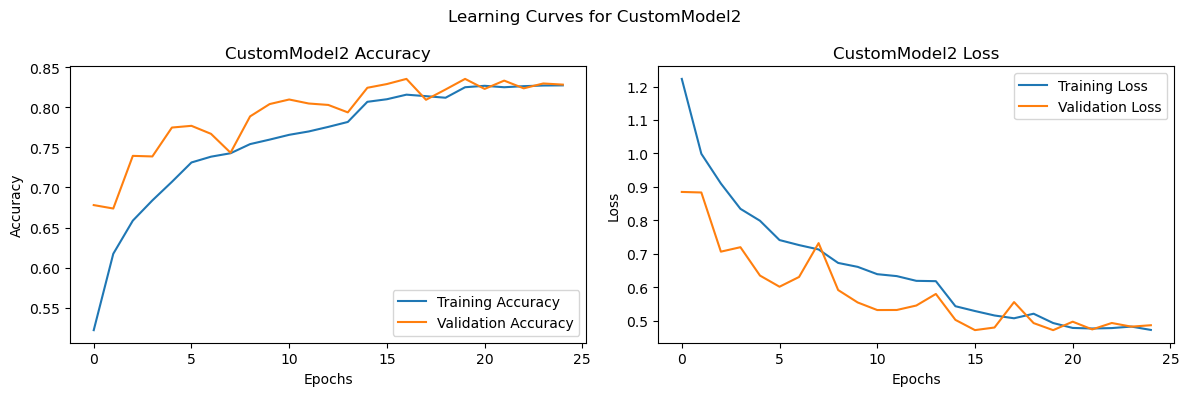

In [16]:
for name, builder in models_info.items():
    print(f"\n🔧 Training {name}...\n")
    model = builder()
    model.summary()
    
    history = train_model(model, train_generator, validation_generator, epochs=25, name=name)
    model_histories[name] = history

    # Plot training history
    plt.figure(figsize=(12, 4))
    
    # Accuracy plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{name} Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{name} Loss')
    plt.legend()

    plt.suptitle(f'Learning Curves for {name}')
    plt.tight_layout()
    plt.savefig(f'results/{name}_accuracy_loss.png')
    plt.show()

### 5.4 Worst Misclassified Examples for MobileNetV2


🔍 Identifying worst misclassified images for MobileNetV2...

94/94 [==============================] - 8s 73ms/step


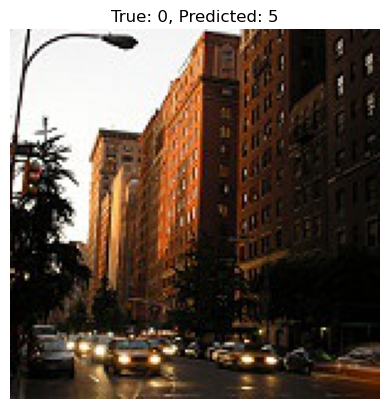

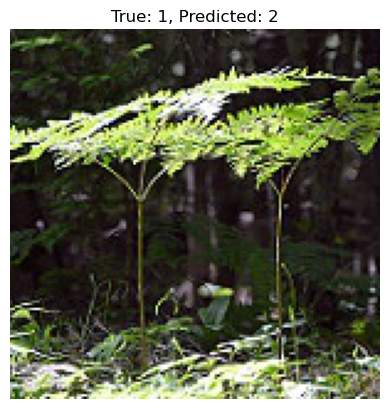

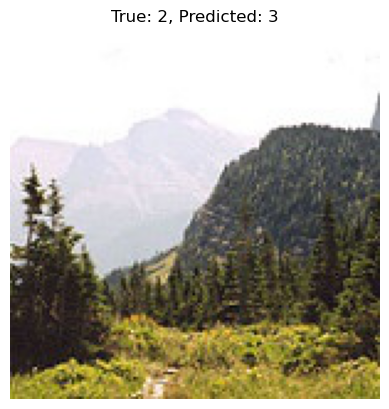

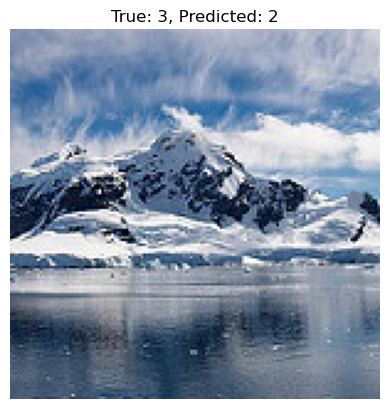

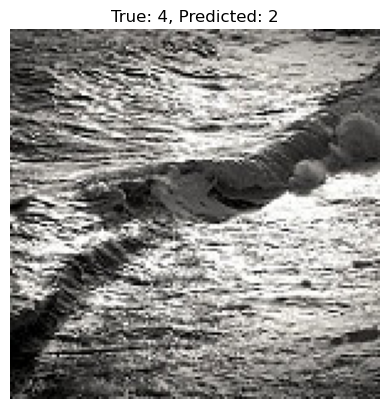

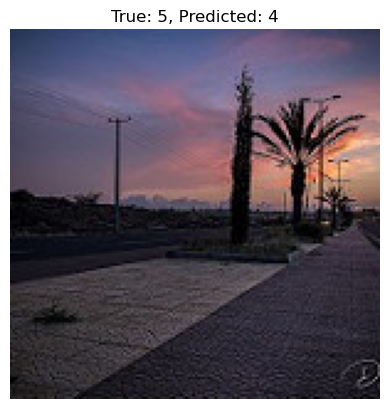

In [17]:
import numpy as np

if 'MobileNetV2' in model_histories:
    print("\n🔍 Identifying worst misclassified images for MobileNetV2...\n")
    model = models_info['MobileNetV2']()

    # Load best weights
    model.load_weights("models/MobileNetV2_best.h5")

    # Collect full test data
    test_images = []
    test_labels = []

    for x, y in test_generator:
        test_images.extend(x)
        test_labels.extend(np.argmax(y, axis=1))
        if len(test_images) >= test_generator.samples:
            break

    test_images = np.array(test_images)
    test_labels = np.array(test_labels)

    predictions = model.predict(test_images, verbose=1)
    predicted_labels = np.argmax(predictions, axis=1)

    prob_diffs = predictions[np.arange(len(test_images)), predicted_labels] - \
                 predictions[np.arange(len(test_images)), test_labels]

    for i in range(6):
        indices = np.where(test_labels == i)[0]
        prob_diffs_i = prob_diffs[indices]
        if len(prob_diffs_i) == 0:
            continue
        worst_idx_rel = np.argmax(prob_diffs_i)
        worst_idx = indices[worst_idx_rel]

        plt.figure()
        plt.imshow(test_images[worst_idx])
        plt.axis('off')
        plt.title(f'True: {i}, Predicted: {predicted_labels[worst_idx]}')
        plt.savefig(f'results/worst_case_class_{i}.png')
        plt.show()


In [20]:
# 🧪 Evaluate all models on the test set and store their test accuracy/loss
test_results = {}

for name, builder in models_info.items():
    print(f"\n📊 Evaluating {name} on test set...")
    model = builder()
    model.load_weights(f"models/{name}_best.h5")
    test_loss, test_acc = model.evaluate(test_generator, verbose=1)
    test_results[name] = {
        'test_accuracy': test_acc,
        'test_loss': test_loss
    }


📊 Evaluating VGG16 on test set...
94/94 [==============================] - 120s 1s/step - loss: 0.3718 - accuracy: 0.8620

📊 Evaluating MobileNetV2 on test set...


c:\ProgramData\anaconda3\envs\new_env\lib\site-packages\tensorflow\python\keras\optimizer_v2\optimizer_v2.py:374: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  warnings.warn(


94/94 [==============================] - 9s 83ms/step - loss: 0.2115 - accuracy: 0.9273

📊 Evaluating CustomModel1 on test set...
94/94 [==============================] - 5s 55ms/step - loss: 0.4689 - accuracy: 0.8407

📊 Evaluating CustomModel2 on test set...
94/94 [==============================] - 5s 50ms/step - loss: 0.4808 - accuracy: 0.8323


### 5.5 Saving Summary Results

In [ ]:
results_df = pd.DataFrame([
    {
        'Model': name,
        'Best Epochs': len(history.history['val_accuracy']),
        'Best Val Accuracy': max(history.history['val_accuracy']),
        'Best Train Accuracy': max(history.history['accuracy']),
        'Best Val Loss': min(history.history['val_loss']),
        'Test Accuracy': test_results[name]['test_accuracy'],
        'Test Loss': test_results[name]['test_loss']
    }
    for name, history in model_histories.items()
])

results_df.to_csv("results/summary.csv", index=False)
results_df

,Model,Best Epochs,Best Val Accuracy,Best Train Accuracy,Best Val Loss,Test Accuracy,Test Loss
0,VGG16,16,0.873752,0.822262,0.356193,0.862000,0.371756
1,MobileNetV2,21,0.929030,0.969012,0.212872,0.927333,0.211462
2,CustomModel1,24,0.824536,0.826002,0.506207,0.840667,0.468857
3,CustomModel2,25,0.835235,0.827159,0.471367,0.832333,0.480804
